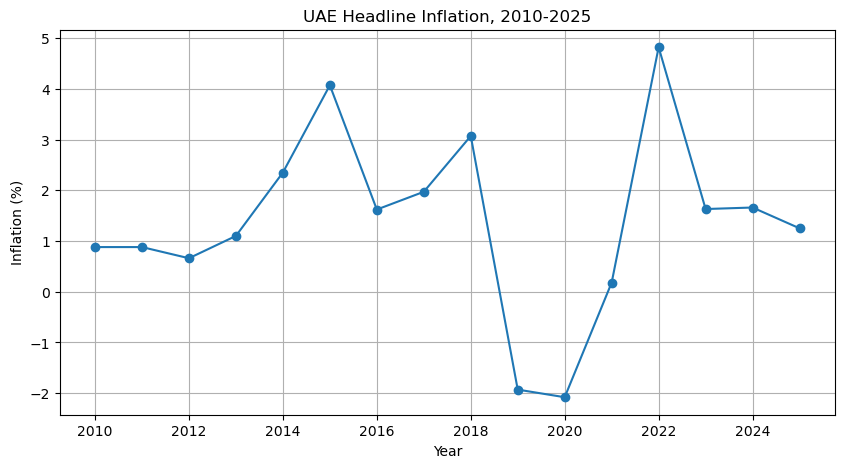

Coefficient: 0.239
R²: 0.058
2026 Forecast: 1.38%


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

df = pd.read_csv(r"C:\Users\Shahe\Downloads\uae_inflation_data.csv")

# Trend chart
plt.figure(figsize=(10,5))
plt.plot(df['year'], df['inflation'], marker='o')
plt.title('UAE Headline Inflation, 2010-2025')
plt.xlabel('Year')
plt.ylabel('Inflation (%)')
plt.grid(True)
plt.savefig('uae_inflation_trend.png')
plt.show()

# Lagged regression
df['inflation_lag1'] = df['inflation'].shift(1)
df_model = df.dropna()

X = df_model[['inflation_lag1']]
y = df_model['inflation']
model = LinearRegression()
model.fit(X, y)

print(f"Coefficient: {model.coef_[0]:.3f}")
print(f"R²: {model.score(X, y):.3f}")

forecast_2026 = model.predict(pd.DataFrame({'inflation_lag1': [1.25]}))
print(f"2026 Forecast: {forecast_2026[0]:.2f}%")

# Export with forecast for Power BI
df['type'] = 'Actual'
forecast_row = pd.DataFrame({'year':[2026],'inflation':[round(forecast_2026[0],2)],'type':['Forecast']})
df_final = pd.concat([df, forecast_row], ignore_index=True)
df_final.to_csv('uae_inflation_with_forecast.csv', index=False)

In [2]:
print("Export complete: uae_inflation_with_forecast.csv")

Export complete: uae_inflation_with_forecast.csv
